# Deforestation Detection Using CNN on Satellite Imagery

### Team Members
- T. Sai Akshaya – 2520030143
- R. Juhit Naidu – 25520030457

### Project Objective
To classify deforestation-related land-use patterns from Landsat satellite images using a Convolutional Neural Network (CNN).


import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Basic libraries imported successfully!")

In [48]:
try:
    import tensorflow as tf
    print("TensorFlow version:", tf.__version__)
except ImportError:
    print("TensorFlow is not installed.")

TensorFlow version: 2.21.0


In [49]:
import os

# Path to the extracted satellite image dataset
DATASET_PATH = r"C:\Users\Srinivas Tati\Downloads\my_examples_landsat_final"

print("Dataset path:")
print(DATASET_PATH)

print("\nDataset folder exists:", os.path.exists(DATASET_PATH))

Dataset path:
C:\Users\Srinivas Tati\Downloads\my_examples_landsat_final

Dataset folder exists: True


In [50]:
# Find all visible RGB satellite images

import os
import glob

# Dataset location
DATASET_PATH = r"C:\Users\Srinivas Tati\Downloads\my_examples_landsat_final"

# Search for all PNG images inside the visible folders
image_paths = glob.glob(
    os.path.join(DATASET_PATH, "*", "images", "visible", "*.png")
)

print("Total RGB satellite images found:", len(image_paths))

# Show first 5 image paths
print("\nFirst 5 images:")
for path in image_paths[:5]:
    print(path)

Total RGB satellite images found: 0

First 5 images:


In [51]:
import os
import glob

DATASET_PATH = r"C:\Users\Srinivas Tati\Downloads\my_examples_landsat_final"

# Find ALL PNG files anywhere inside the dataset
image_paths = glob.glob(
    os.path.join(DATASET_PATH, "**", "*.png"),
    recursive=True
)

print("Total PNG images found:", len(image_paths))

print("\nFirst 5 PNG files:")
for path in image_paths[:5]:
    print(path)

Total PNG images found: 3108

First 5 PNG files:
C:\Users\Srinivas Tati\Downloads\my_examples_landsat_final\my_examples_landsat_final\10.014311051001007_3.9690156134753534\images\visible\2019_10.014311051001007_3.9690156134753534.png
C:\Users\Srinivas Tati\Downloads\my_examples_landsat_final\my_examples_landsat_final\10.015125000000001_3.327125\images\visible\2020_10.015125000000001_3.327125.png
C:\Users\Srinivas Tati\Downloads\my_examples_landsat_final\my_examples_landsat_final\10.017809290629039_3.9747994659212513\images\visible\2019_10.017809290629039_3.9747994659212513.png
C:\Users\Srinivas Tati\Downloads\my_examples_landsat_final\my_examples_landsat_final\10.01857144327856_3.9749781904573354\images\visible\2019_10.01857144327856_3.9749781904573354.png
C:\Users\Srinivas Tati\Downloads\my_examples_landsat_final\my_examples_landsat_final\10.02568236826734_5.592411467355677\images\visible\2020_10.02568236826734_5.592411467355677.png


Image size: (332, 332)
Image mode: RGBA


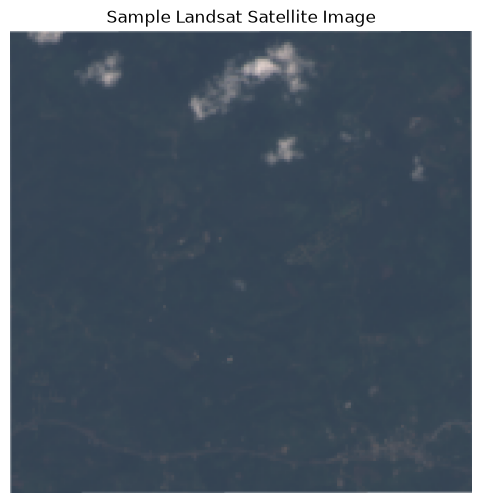

In [52]:
# Check one satellite image

from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(image_paths[0])

print("Image size:", img.size)
print("Image mode:", img.mode)

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")
plt.title("Sample Landsat Satellite Image")
plt.show()

In [53]:
import os

LABEL_PATH = r"C:\Users\Srinivas Tati\OneDrive\Documents\GitHub\ML-Project\data\labels\all"

print("Label file exists:", os.path.exists(LABEL_PATH))


Label file exists: False


In [54]:
import os

# Search for the label file inside the extracted labels folder
LABELS_ROOT = r"C:\Users\Srinivas Tati\Downloads"

label_files = []

for root, dirs, files in os.walk(LABELS_ROOT):
    for file in files:
        if file.lower() == "all.csv" or file.lower() == "all.xls" or file.lower() == "all.xlsx":
            label_files.append(os.path.join(root, file))

print("Label files found:")

for file in label_files:
    print(file)

Label files found:
C:\Users\Srinivas Tati\Downloads\labels\labels\Landsat final versions\detailed\all.csv
C:\Users\Srinivas Tati\Downloads\labels\labels\Landsat final versions\groups\all.csv
C:\Users\Srinivas Tati\Downloads\labels\labels\Landsat final versions\time_series\all.csv
C:\Users\Srinivas Tati\Downloads\labels\labels\Planet final versions\detailed\all.csv
C:\Users\Srinivas Tati\Downloads\labels\labels\Planet final versions\groups\all.csv
C:\Users\Srinivas Tati\Downloads\labels\labels\Planet final versions\time_series\all.csv


In [55]:
import os

# Search Downloads for the label file
SEARCH_ROOT = r"C:\Users\Srinivas Tati\Downloads"

label_files = []

for root, dirs, files in os.walk(SEARCH_ROOT):
    for file in files:
        if file.lower() in ["all.csv", "all.xls", "all.xlsx"]:
            label_files.append(os.path.join(root, file))

print("Label files found:")

for file in label_files:
    print(file)

Label files found:
C:\Users\Srinivas Tati\Downloads\labels\labels\Landsat final versions\detailed\all.csv
C:\Users\Srinivas Tati\Downloads\labels\labels\Landsat final versions\groups\all.csv
C:\Users\Srinivas Tati\Downloads\labels\labels\Landsat final versions\time_series\all.csv
C:\Users\Srinivas Tati\Downloads\labels\labels\Planet final versions\detailed\all.csv
C:\Users\Srinivas Tati\Downloads\labels\labels\Planet final versions\groups\all.csv
C:\Users\Srinivas Tati\Downloads\labels\labels\Planet final versions\time_series\all.csv


In [56]:
import os

print(os.listdir(
    r"C:\Users\Srinivas Tati\OneDrive\Documents\GitHub\ML-Project\Project\DATA"
))

['my_examples_landsat_final']


In [57]:
import pandas as pd

LABEL_PATH = r"C:\Users\Srinivas Tati\OneDrive\Documents\GitHub\ML-Project\Project\DATA\my_examples_landsat_final\all.csv"

labels_df = pd.read_csv(LABEL_PATH)

print("Labels loaded successfully!")
print("Shape:", labels_df.shape)
print("Columns:", labels_df.columns.tolist())

Labels loaded successfully!
Shape: (3108, 6)
Columns: ['label', 'merged_label', 'latitude', 'longitude', 'year', 'example_path']


In [58]:
print("Class distribution:")
print(labels_df["merged_label"].value_counts())

print("\nClass percentages:")
print(
    (labels_df["merged_label"].value_counts(normalize=True) * 100)
    .round(2)
)

Class distribution:
merged_label
Other                      1198
Plantation                 1010
Smallholder agriculture     803
Grassland shrubland          97
Name: count, dtype: int64

Class percentages:
merged_label
Other                      38.55
Plantation                 32.50
Smallholder agriculture    25.84
Grassland shrubland         3.12
Name: proportion, dtype: float64


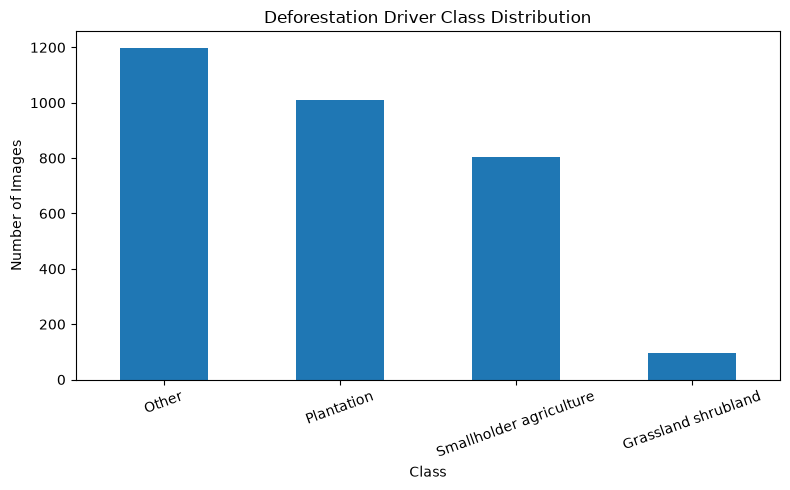

In [59]:
import matplotlib.pyplot as plt

class_counts = labels_df["merged_label"].value_counts()

plt.figure(figsize=(8, 5))
class_counts.plot(kind="bar")
plt.title("Deforestation Driver Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [60]:
# Show the exact class counts

class_counts = labels_df["merged_label"].value_counts()

print("Number of samples in each class:")
for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")

print("\nTotal labelled samples:", class_counts.sum())

Number of samples in each class:
Other: 1198
Plantation: 1010
Smallholder agriculture: 803
Grassland shrubland: 97

Total labelled samples: 3108


In [61]:
class_percent = (class_counts / class_counts.sum()) * 100

print("Class distribution:")
for class_name, percentage in class_percent.items():
    print(f"{class_name}: {percentage:.2f}%")

Class distribution:
Other: 38.55%
Plantation: 32.50%
Smallholder agriculture: 25.84%
Grassland shrubland: 3.12%


In [62]:
class_percent = (class_counts / class_counts.sum()) * 100

print("Class distribution:")
for class_name, percentage in class_percent.items():
    print(f"{class_name}: {percentage:.2f}%")
    

Class distribution:
Other: 38.55%
Plantation: 32.50%
Smallholder agriculture: 25.84%
Grassland shrubland: 3.12%


In [63]:
import os
import glob

image_paths = glob.glob(
    os.path.join(DATASET_PATH, "**", "images", "visible", "*.png"),
    recursive=True
)

print("Total images found:", len(image_paths))

print("\nFirst 5 image paths:")
for path in image_paths[:5]:
    print(path)

Total images found: 3108

First 5 image paths:
C:\Users\Srinivas Tati\Downloads\my_examples_landsat_final\my_examples_landsat_final\10.014311051001007_3.9690156134753534\images\visible\2019_10.014311051001007_3.9690156134753534.png
C:\Users\Srinivas Tati\Downloads\my_examples_landsat_final\my_examples_landsat_final\10.015125000000001_3.327125\images\visible\2020_10.015125000000001_3.327125.png
C:\Users\Srinivas Tati\Downloads\my_examples_landsat_final\my_examples_landsat_final\10.017809290629039_3.9747994659212513\images\visible\2019_10.017809290629039_3.9747994659212513.png
C:\Users\Srinivas Tati\Downloads\my_examples_landsat_final\my_examples_landsat_final\10.01857144327856_3.9749781904573354\images\visible\2019_10.01857144327856_3.9749781904573354.png
C:\Users\Srinivas Tati\Downloads\my_examples_landsat_final\my_examples_landsat_final\10.02568236826734_5.592411467355677\images\visible\2020_10.02568236826734_5.592411467355677.png


In [64]:
import os
import pandas as pd

# Create a dictionary using the coordinate folder name
image_dict = {}

for path in image_paths:
    folder_name = os.path.basename(os.path.dirname(os.path.dirname(os.path.dirname(path))))
    image_dict[folder_name] = path

print("Images indexed:", len(image_dict))

Images indexed: 3108


In [65]:
# Check the label columns first
print("Label columns:")
print(labels_df.columns.tolist())

print("\nNumber of labels:", len(labels_df))
print("Number of images:", len(image_paths))

Label columns:
['label', 'merged_label', 'latitude', 'longitude', 'year', 'example_path']

Number of labels: 3108
Number of images: 3108


In [66]:
import os

# Create a mapping from coordinate folder name to image path
image_dict = {}

for path in image_paths:
    coordinate_folder = os.path.basename(
        os.path.dirname(
            os.path.dirname(
                os.path.dirname(path)
            )
        )
    )
    image_dict[coordinate_folder] = path

print("Images indexed:", len(image_dict))

Images indexed: 3108


In [67]:
# Create the final image-label dataframe

image_label_df = labels_df.copy()

def find_image(example_path):
    coordinate_folder = os.path.basename(example_path.rstrip("/\\"))
    return image_dict.get(coordinate_folder)

image_label_df["image_path"] = image_label_df["example_path"].apply(find_image)

print("Total records:", len(image_label_df))
print("Images successfully matched:", image_label_df["image_path"].notna().sum())
print("Images not matched:", image_label_df["image_path"].isna().sum())

Total records: 3108
Images successfully matched: 3108
Images not matched: 0


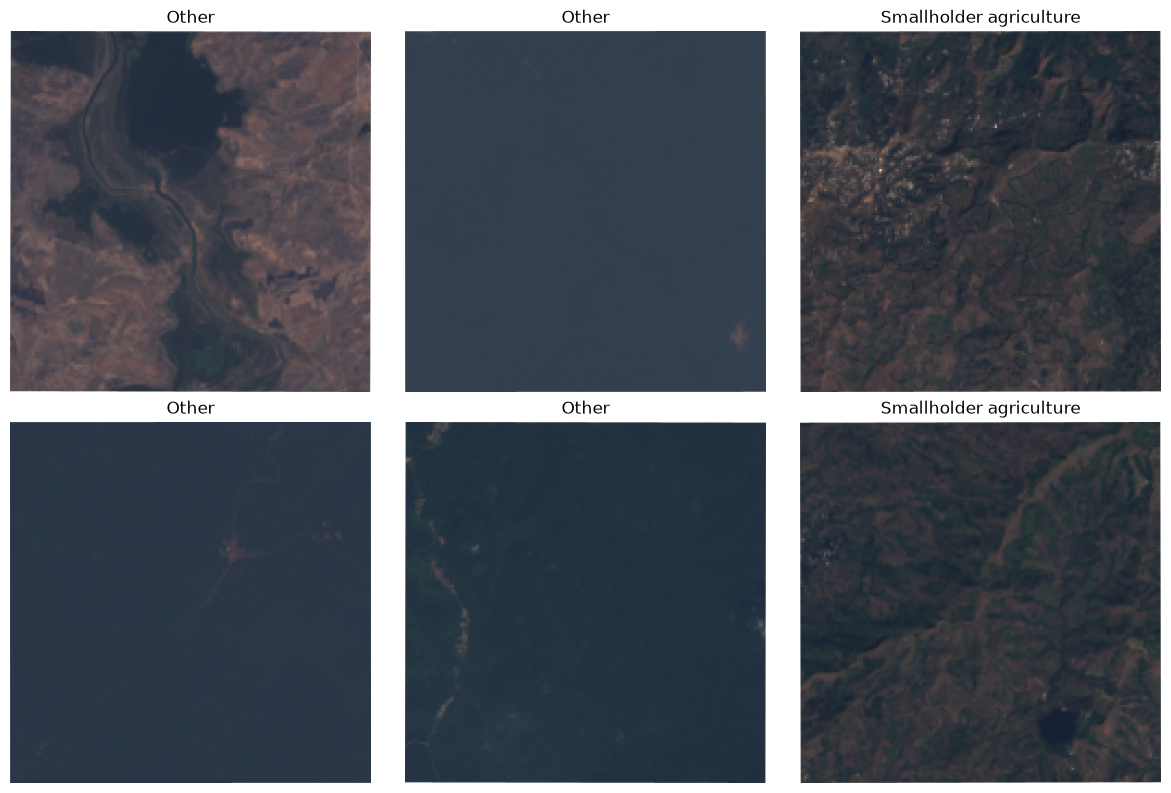

In [68]:
import matplotlib.pyplot as plt

# Display 6 sample images with their labels
sample_df = image_label_df.sample(6, random_state=42)

plt.figure(figsize=(12, 8))

for i, (_, row) in enumerate(sample_df.iterrows()):
    img = Image.open(row["image_path"])

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(row["merged_label"])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [69]:
# Check the four classes and assign numerical labels

class_names = sorted(image_label_df["merged_label"].unique())

print("Classes:")
for i, class_name in enumerate(class_names):
    print(i, "=", class_name)

print("\nNumber of classes:", len(class_names))

Classes:
0 = Grassland shrubland
1 = Other
2 = Plantation
3 = Smallholder agriculture

Number of classes: 4


In [70]:
# Convert class names into numerical labels

class_to_index = {
    class_name: index
    for index, class_name in enumerate(class_names)
}

image_label_df["class_index"] = image_label_df["merged_label"].map(class_to_index)

print(image_label_df[["merged_label", "class_index"]].head(10))

print("\nClass mapping:")
print(class_to_index)

  merged_label  class_index
0   Plantation            2
1   Plantation            2
2   Plantation            2
3   Plantation            2
4   Plantation            2
5   Plantation            2
6   Plantation            2
7   Plantation            2
8   Plantation            2
9   Plantation            2

Class mapping:
{'Grassland shrubland': 0, 'Other': 1, 'Plantation': 2, 'Smallholder agriculture': 3}


In [71]:
from sklearn.model_selection import train_test_split

# First split: 70% training, 30% temporary
train_df, temp_df = train_test_split(
    image_label_df,
    test_size=0.30,
    random_state=42,
    stratify=image_label_df["class_index"]
)

# Second split: divide the temporary 30% equally
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["class_index"]
)

print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Testing samples:", len(test_df))
print("Total samples:", len(train_df) + len(val_df) + len(test_df))

Training samples: 2175
Validation samples: 466
Testing samples: 467
Total samples: 3108


In [72]:
import numpy as np
from PIL import Image

IMG_SIZE = 128

def load_images(dataframe):
    images = []
    labels = []

    for _, row in dataframe.iterrows():
        img = Image.open(row["image_path"]).convert("RGB")
        img = img.resize((IMG_SIZE, IMG_SIZE))

        images.append(np.array(img) / 255.0)
        labels.append(row["class_index"])

    return np.array(images, dtype=np.float32), np.array(labels, dtype=np.int32)


# Load training, validation and testing images
X_train, y_train = load_images(train_df)
X_val, y_val = load_images(val_df)
X_test, y_test = load_images(test_df)

print("Training images shape:", X_train.shape)
print("Training labels shape:", y_train.shape)

print("Validation images shape:", X_val.shape)
print("Validation labels shape:", y_val.shape)

print("Testing images shape:", X_test.shape)
print("Testing labels shape:", y_test.shape)

Training images shape: (2175, 128, 128, 3)
Training labels shape: (2175,)
Validation images shape: (466, 128, 128, 3)
Validation labels shape: (466,)
Testing images shape: (467, 128, 128, 3)
Testing labels shape: (467,)


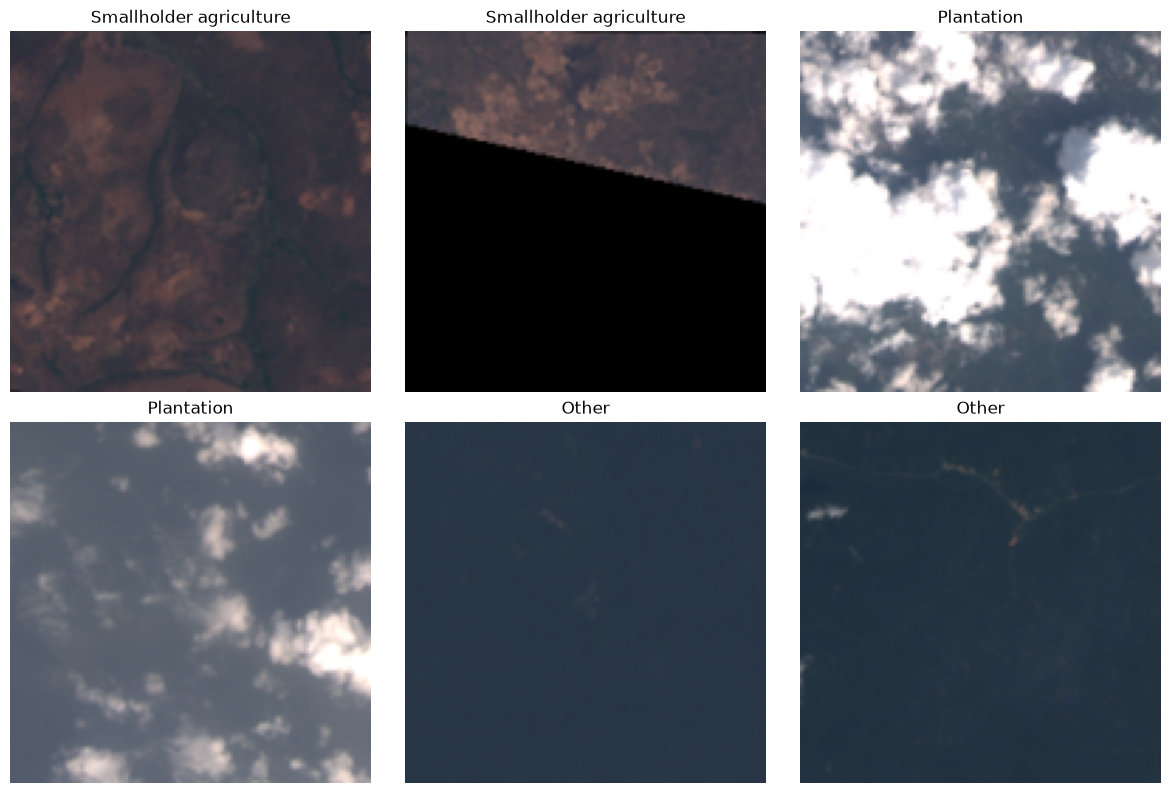

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [74]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Build CNN model
model = models.Sequential([
    
    # First convolution block
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(128, 128, 3)),
    layers.MaxPooling2D((2, 2)),

    # Second convolution block
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Third convolution block
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Convert feature maps to a vector
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    # Output layer: 4 classes
    layers.Dense(4, activation="softmax")
])

model.summary()

C:\Users\Srinivas Tati\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [75]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("CNN model compiled successfully!")

CNN model compiled successfully!


In [76]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,
    verbose=1
)

Epoch 1/15
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 109ms/step - accuracy: 0.3710 - loss: 1.2215 - val_accuracy: 0.4936 - val_loss: 1.1030
Epoch 2/15
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 114ms/step - accuracy: 0.4667 - loss: 1.1044 - val_accuracy: 0.4914 - val_loss: 1.1045
Epoch 3/15
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 117ms/step - accuracy: 0.4864 - loss: 1.0705 - val_accuracy: 0.5429 - val_loss: 1.0378
Epoch 4/15
68/68 ━━━━━━━━━━━━━━━━━━━━ 7s 102ms/step - accuracy: 0.5122 - loss: 1.0338 - val_accuracy: 0.5558 - val_loss: 0.9659
Epoch 5/15
68/68 ━━━━━━━━━━━━━━━━━━━━ 7s 106ms/step - accuracy: 0.5347 - loss: 0.9855 - val_accuracy: 0.6137 - val_loss: 0.9224
Epoch 6/15
68/68 ━━━━━━━━━━━━━━━━━━━━ 7s 107ms/step - accuracy: 0.5577 - loss: 0.9734 - val_accuracy: 0.6159 - val_loss: 0.9071
Epoch 7/15
68/68 ━━━━━━━━━━━━━━━━━━━━ 7s 104ms/step - accuracy: 0.5669 - loss: 0.9506 - val_accuracy: 0.6159 - val_loss: 0.8477
Epoch 8/15
68/68 ━━━━━━━━━━━━━━━━━━━━ 7s 108ms/step - accuracy: 0.5926 - loss: 0.9036 - val_accuracy: 0.

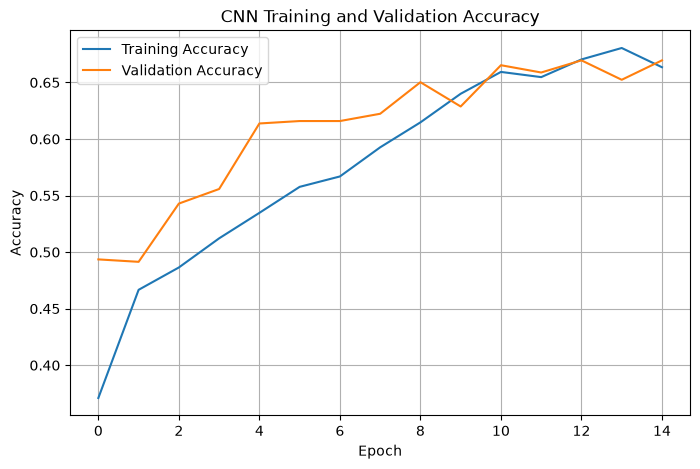

In [77]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("CNN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

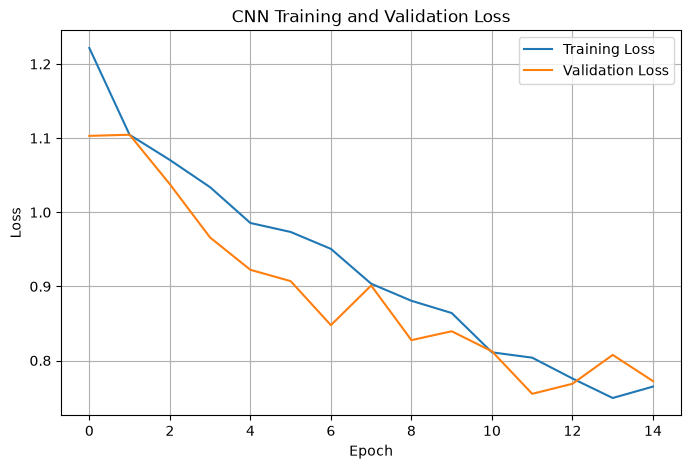

In [78]:
# Plot training and validation loss
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("CNN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [79]:
# Evaluate CNN on the test dataset

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6788 - loss: 0.8416

Test Loss: 0.8415886163711548
Test Accuracy: 0.6788008809089661
Test Accuracy (%): 67.8800880908966


In [80]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt

# Get predictions
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Classification report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names,
        zero_division=0
    )
)

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step
Confusion Matrix:
[[  0  14   0   0]
 [  0 125  41  14]
 [  0  33 106  13]
 [  0  29   6  86]]

Classification Report:
                         precision    recall  f1-score   support

    Grassland shrubland       0.00      0.00      0.00        14
                  Other       0.62      0.69      0.66       180
             Plantation       0.69      0.70      0.70       152
Smallholder agriculture       0.76      0.71      0.74       121

               accuracy                           0.68       467
              macro avg       0.52      0.53      0.52       467
           weighted avg       0.66      0.68      0.67       467



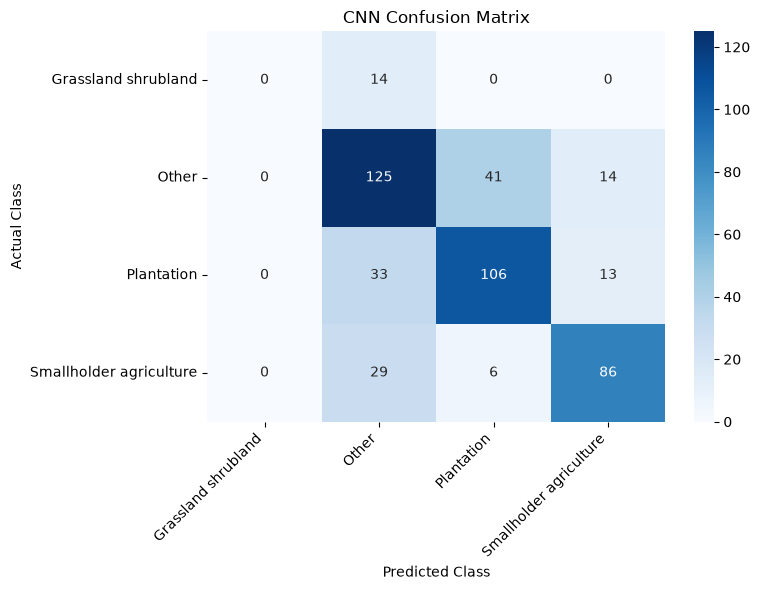

In [81]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("CNN Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

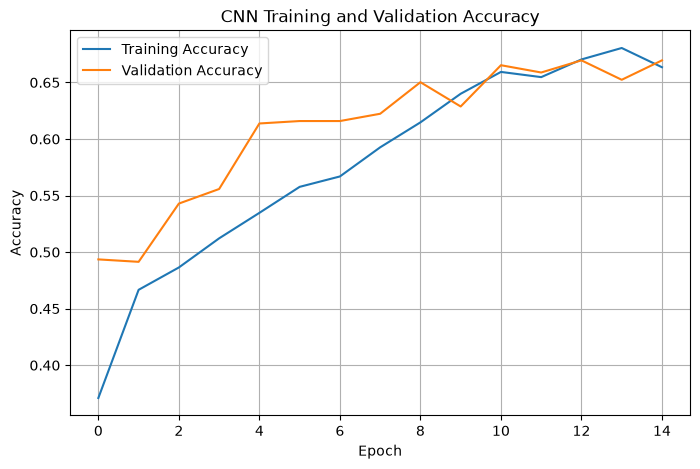

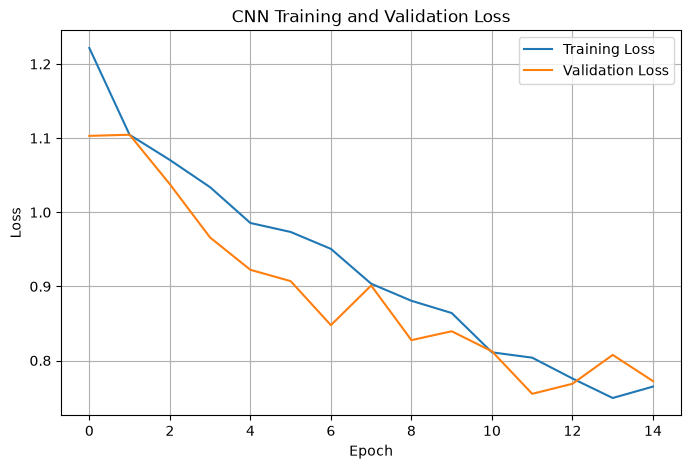

In [82]:
import matplotlib.pyplot as plt

# Training and validation accuracy
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


# Training and validation loss
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [83]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(
    y_test, y_pred, average="weighted", zero_division=0
)
recall = recall_score(
    y_test, y_pred, average="weighted", zero_division=0
)
f1 = f1_score(
    y_test, y_pred, average="weighted", zero_division=0
)

print("FINAL CNN EVALUATION")
print("--------------------")
print(f"Accuracy  : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

FINAL CNN EVALUATION
--------------------
Accuracy  : 0.6788 (67.88%)
Precision : 0.6624
Recall    : 0.6788
F1-Score  : 0.6696


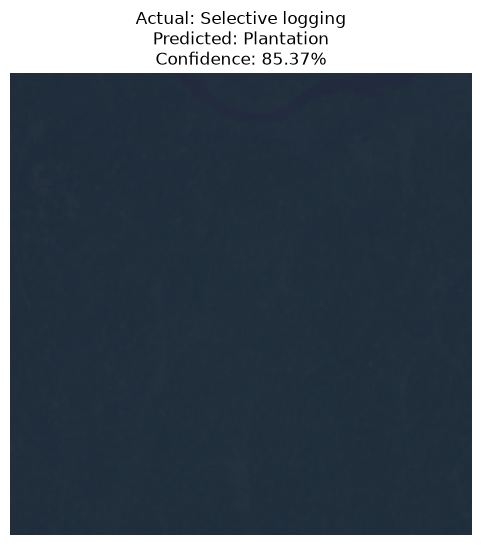

FINAL PREDICTION
----------------
Actual Class    : Selective logging
Predicted Class : Plantation
Confidence      : 85.37%


In [84]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Select one test image
sample_index = 0

sample_path = test_df.iloc[sample_index]["image_path"]
actual_class = test_df.iloc[sample_index]["label"]

# Load and preprocess image
image = Image.open(sample_path).convert("RGB")
image_resized = image.resize((128, 128))

image_array = np.array(image_resized) / 255.0
image_input = np.expand_dims(image_array, axis=0)

# Predict
prediction = model.predict(image_input, verbose=0)
predicted_index = np.argmax(prediction)
predicted_class = class_names[predicted_index]
confidence = prediction[0][predicted_index] * 100

# Display image
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title(
    f"Actual: {actual_class}\n"
    f"Predicted: {predicted_class}\n"
    f"Confidence: {confidence:.2f}%"
)
plt.show()

print("FINAL PREDICTION")
print("----------------")
print("Actual Class    :", actual_class)
print("Predicted Class :", predicted_class)
print(f"Confidence      : {confidence:.2f}%")

In [85]:
import os

print("Dataset exists:", os.path.exists(DATASET_PATH))
print("Labels exist:", os.path.exists(LABEL_PATH))

Dataset exists: True
Labels exist: True


In [86]:
import pandas as pd

labels_df = pd.read_csv(LABEL_PATH)

print("Labels loaded successfully!")
print("Shape:", labels_df.shape)

Labels loaded successfully!
Shape: (3108, 6)
